### HuyIGW04 - Non-linear processing using MLP

In [192]:
# non-linear data
!gdown --quiet 1SqSn_8rxkk-Qvu4JLMcN_3ZFGDNa6P_V

In [193]:
# lib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### **Specification**
- Đọc data, đặt torch, chia seed.  
- Chia theo 7/2/1. Có shuffle.  
- **Data normalization**: scale bằng `StandardScaler` và chuyển train/val/test về `torch` (X có type là **float32**, y có type là **long**)  
- **Mini-batch training**: xây dựng class  `CustomDataset` để gom train, val và test. Sau đó dùng `DataLoader` để chia batch. Test không cần chia.  
- **Model Construction**: xây dựng class MLP gồm 1 lớp ẩn, 1 `output` layer và activation function là **ReLU**. Thiết lập `model` sau khi xây dựng (node=128).  
- **Model Compilation**: Xây dựng `loss` là **Cross Entropy**, `optimizer` là **SGD** và và hàm đánh giá là Accuracy (input gồm `y_hat`, `y_true`).  
- **Training**: thực hiện với flow của PyTorch, riêng accuracy phải biết đổi `y_hat` bằng cách loại khỏi grad bằng detach().cpu() rồi thêm vào list. Chút nữa lấy list đó đi `cat` lại bởi PyTorch. Tương tự cho y_true, khi này mới sử dụng hàm evaluation tính được.  
- **visualization**: Hiển thị cả 4 đồ thị bằng `subplots(2, 2, figsize)`. (mỗi hình sử dụng `plot` để plot và `set` để set x và y.)  
- **Evaluation**:  acc ~ 0.9333. Nếu dùng Softmax thay vì ReLU -> 0.6.

In [194]:
# read and show data attribution
PATH = 'NonLinear_data.npy'
data = np.load(PATH, allow_pickle=True)
data.item().keys()

dict_keys(['X', 'labels'])

In [195]:
X = data.item()['X']
y = data.item()['labels']
print(f'X.shape: {X.shape}')
print(f'y.shape: {y.shape}')

X.shape: (300, 2)
y.shape: (300,)


In [196]:
# setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# seed
random_seed = 10
np.random.seed(random_seed)        # for numpy
if torch.cuda.is_available():      # for PyTorch
    torch.manual_seed(random_seed)

In [197]:
# split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=random_seed, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.125, random_state=random_seed, shuffle=True)

print(f'train set: {X_train.shape}')
print(f'val set: {X_val.shape}')
print(f'test set: {X_test.shape}')

train set: (210, 2)
val set: (60, 2)
test set: (30, 2)


In [198]:
# data normalization
scaler_model = StandardScaler()
X_train = scaler_model.fit_transform(X_train)
X_val = scaler_model.transform(X_val)
X_test = scaler_model.transform(X_test)

# convert to PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_val = torch.tensor(y_val, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

print(f'train/val/test size: {X_train.shape}, {X_val.shape}, {X_test.shape} \n')
print(f'type of input: {X_train.dtype}')
print(f'type of label: {y_train.dtype}')

train/val/test size: torch.Size([210, 2]), torch.Size([60, 2]), torch.Size([30, 2]) 

type of input: torch.float32
type of label: torch.int64


In [199]:
# mini-batch training
class CustomSet(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

try:
    train_set = CustomSet(X_train, y_train)
    val_set = CustomSet(X_val, y_val)
    test_set = CustomSet(X_test, y_test)
except Exception as e:
    raise RuntimeError('class CustomSet is not valid') from e

# unique train/val/test
train = DataLoader(dataset=train_set,
                   batch_size=16,
                   shuffle=True)

val = DataLoader(dataset=val_set,
                 batch_size=16,
                 shuffle=True)
test = DataLoader(dataset=test_set,
                  batch_size=8,
                  shuffle=True)

print(type(train))

<class 'torch.utils.data.dataloader.DataLoader'>


In [200]:
# model construction
class MLP(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, hidden_dim)
        self.output = nn.Linear(hidden_dim, out_features)
    
    def forward(self, x):
        x = self.linear(x)
        x = F.relu(x)
        out = self.output(x)
        return out

in_feature = X_train.shape[1]
hidden = 64
out_feature = len(torch.unique(y_train, dim=0))
model = MLP(in_feature, hidden, out_feature).to(device)

In [201]:
# loss, optimizer 
lr = 1e-1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [202]:
# evaluation
def accuracy_eval(y_pred: torch.Tensor, y_true: torch.Tensor):
    y_pred = y_pred.to(device)
    y_true = y_true.to(device)
    y_true_label = torch.argmax(y_pred, dim=1)
    true_pred = torch.sum(y_true_label == y_true).item()
    acc = true_pred/len(y_true)
    return acc

# test
y_hat_ex = model(X_train)
accuracy_eval(y_hat_ex, y_train)

0.3142857142857143

In [203]:
# training
epochs = 90
train_losses = []
val_losses = []
train_acc = []
val_acc = []

for epoch in range(epochs):
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_acc = []
    epoch_val_acc = []

    model.train()
    for _, (X_train_batch, y_train_batch) in enumerate(train):
        X_train_batch = X_train_batch.to(device)
        y_train_batch = y_train_batch.to(device)
        y_train_hat = model(X_train_batch)
        optimizer.zero_grad()
        train_loss_batch = criterion(y_train_hat, y_train_batch)
        train_loss_batch.backward()
        optimizer.step()

        epoch_train_losses.append(train_loss_batch.item())
        acc_train_batch = accuracy_eval(y_train_hat, y_train_batch)
        epoch_train_acc.append(acc_train_batch)        
    
    model.eval()
    with torch.no_grad():
        epoch_train_loss = sum(epoch_train_losses)/len(epoch_train_losses)
        train_losses.append(epoch_train_loss)
        
        epoch_train_acc = sum(epoch_train_acc)/len(epoch_train_acc)
        train_acc.append(epoch_train_acc)

        # validation
        for _, (X_train_val, y_train_val) in enumerate(val):
            X_train_val = X_train_val.to(device)
            y_train_val = y_train_val.to(device)
            y_val_hat = model(X_train_val)
            
            loss_val_batch = criterion(y_val_hat, y_train_val)
            epoch_val_losses.append(loss_val_batch.item())
            
            acc_val_batch = accuracy_eval(y_val_hat, y_train_val)
            epoch_val_acc.append(acc_val_batch)
        
        val_loss = sum(epoch_val_losses)/len(epoch_val_losses)
        val_losses.append(val_loss)

        val_acc_value = sum(epoch_val_acc)/len(epoch_val_acc)
        val_acc.append(val_acc_value)
    
    # for debug
    if (epoch % 5 == 4):
        print(f'EPOCH {epoch + 1}:   train_loss = {epoch_train_loss},   val_loss = {val_loss},   train_acc = {round(epoch_train_acc, 3)},     val_acc = {round(val_acc_value, 3)}  ')



EPOCH 5:   train_loss = 0.7002328293664115,   val_loss = 0.6617664843797684,   train_acc = 0.634,     val_acc = 0.656  
EPOCH 10:   train_loss = 0.5960746386221477,   val_loss = 0.5728715360164642,   train_acc = 0.665,     val_acc = 0.745  
EPOCH 15:   train_loss = 0.5201886977468219,   val_loss = 0.5204819738864899,   train_acc = 0.741,     val_acc = 0.75  
EPOCH 20:   train_loss = 0.46633260377815794,   val_loss = 0.49791809916496277,   train_acc = 0.741,     val_acc = 0.75  
EPOCH 25:   train_loss = 0.37831439077854156,   val_loss = 0.33778151497244835,   train_acc = 0.866,     val_acc = 0.859  
EPOCH 30:   train_loss = 0.32719708872692926,   val_loss = 0.27906107529997826,   train_acc = 0.902,     val_acc = 0.932  
EPOCH 35:   train_loss = 0.28985264897346497,   val_loss = 0.24240881949663162,   train_acc = 0.902,     val_acc = 0.938  
EPOCH 40:   train_loss = 0.269739887544087,   val_loss = 0.22522402182221413,   train_acc = 0.915,     val_acc = 0.969  
EPOCH 45:   train_loss = 0.

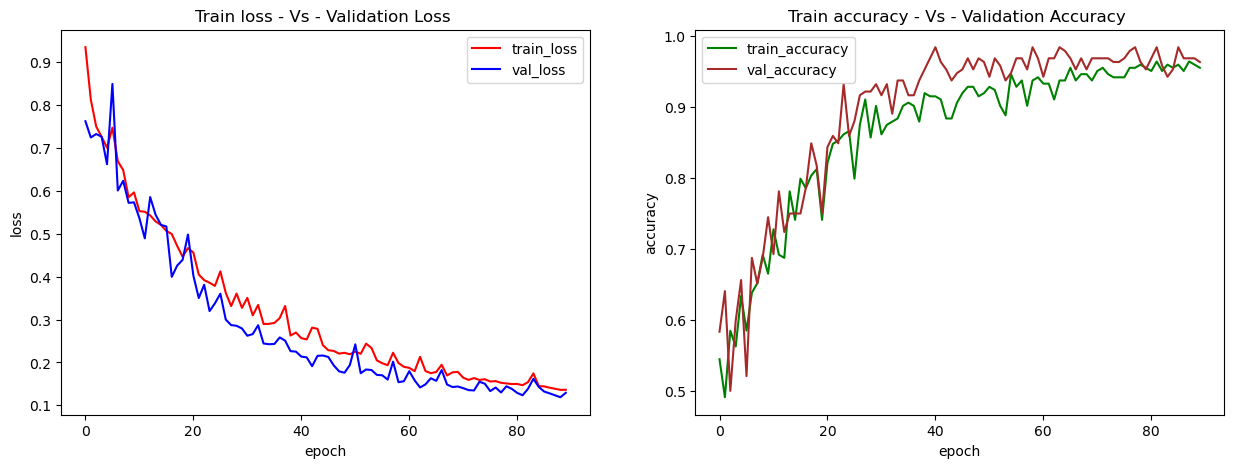

In [204]:
_, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].set_title('Train loss - Vs - Validation Loss ')
ax[0].plot(train_losses, color='red', label='train_loss')
ax[0].plot(val_losses, color='blue', label='val_loss')
ax[0].set(xlabel='epoch', ylabel='loss')
ax[0].legend()


ax[1].set_title('Train accuracy - Vs - Validation Accuracy ')
ax[1].plot(train_acc, color='green', label='train_accuracy')
ax[1].plot(val_acc, color='brown', label='val_accuracy')
ax[1].set(xlabel='epoch', ylabel='accuracy')
ax[1].legend()

plt.show()

In [205]:
# evaluation
test_acc = []
for _, (X_test_batch, y_test_batch) in enumerate(test):
    X_test_batch = X_test_batch.to(device)
    y_test_batch = y_test_batch.to(device)
    y_hat_test = model(X_test_batch)
    acc = accuracy_eval(y_hat_test, y_test_batch)
    test_acc.append(acc)

metric = sum(test_acc)/len(test_acc)
print('Accuracy of test set: {}'.format(round(metric, 4)))

Accuracy of test set: 0.9688
